In [14]:
# //both classification and regression for the non-linear dataset -decision UnicodeTranslateError
#setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error,confusion_matrix, classification_report

from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, ShuffleSplit
from sklearn.model_selection import validation_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


from sklearn.preprocessing import StandardScaler,PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.tree import export_text




In [6]:
np.random.seed(306)

In [8]:
# let's use shuffle split as cv=10 splits and test_size=0.2, random_state=306
cv=ShuffleSplit(n_splits=10,test_size=0.2,random_state=306)


In [10]:
# load the    dataset
features,labels=fetch_california_housing(return_X_y=True,as_frame=True)

com_train_features,test_features,com_train_labels,test_labels=train_test_split(features,labels,random_state=42)
# train=train+dev split
train_features,dev_features,train_lables,dev_labels=train_test_split(com_train_features,com_train_labels,random_state=42)


In [22]:
# Model setup
dt_reg_pipeline=Pipeline([
  ('feature_scaling',StandardScaler()),
  ('dt_reg',DecisionTreeRegressor(max_depth=3,random_state=42))
])


dt_reg_cv_results=cross_validate(dt_reg_pipeline,
                                  com_train_features,
                                  com_train_labels,
                                  cv=cv,
                                  scoring='neg_mean_absolute_error',
                                  return_train_score=True,
                                  return_estimator=True)

dt_reg_train_error=-1*dt_reg_cv_results['train_score']
dt_reg_test_error=-1*dt_reg_cv_results['test_score']
print(dt_reg_train_error.mean(),dt_reg_test_error.mean())
print(dt_reg_train_error.std(),dt_reg_test_error.std())


0.5881423125768466 0.5971396488645839
0.00470561835393329 0.006903593764456573


**Visualize the tree**

In [26]:
# as a tree diagram , text based diagram
# need fit and pipeline
dt_reg_pipeline.fit(train_features,train_lables)
Pipeline(steps=[
  ('feature_scaling',StandardScaler()),
  ('dt_reg',DecisionTreeRegressor(max_depth=3,random_state=42))
])

,steps,"[('feature_scaling', ...), ('dt_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2


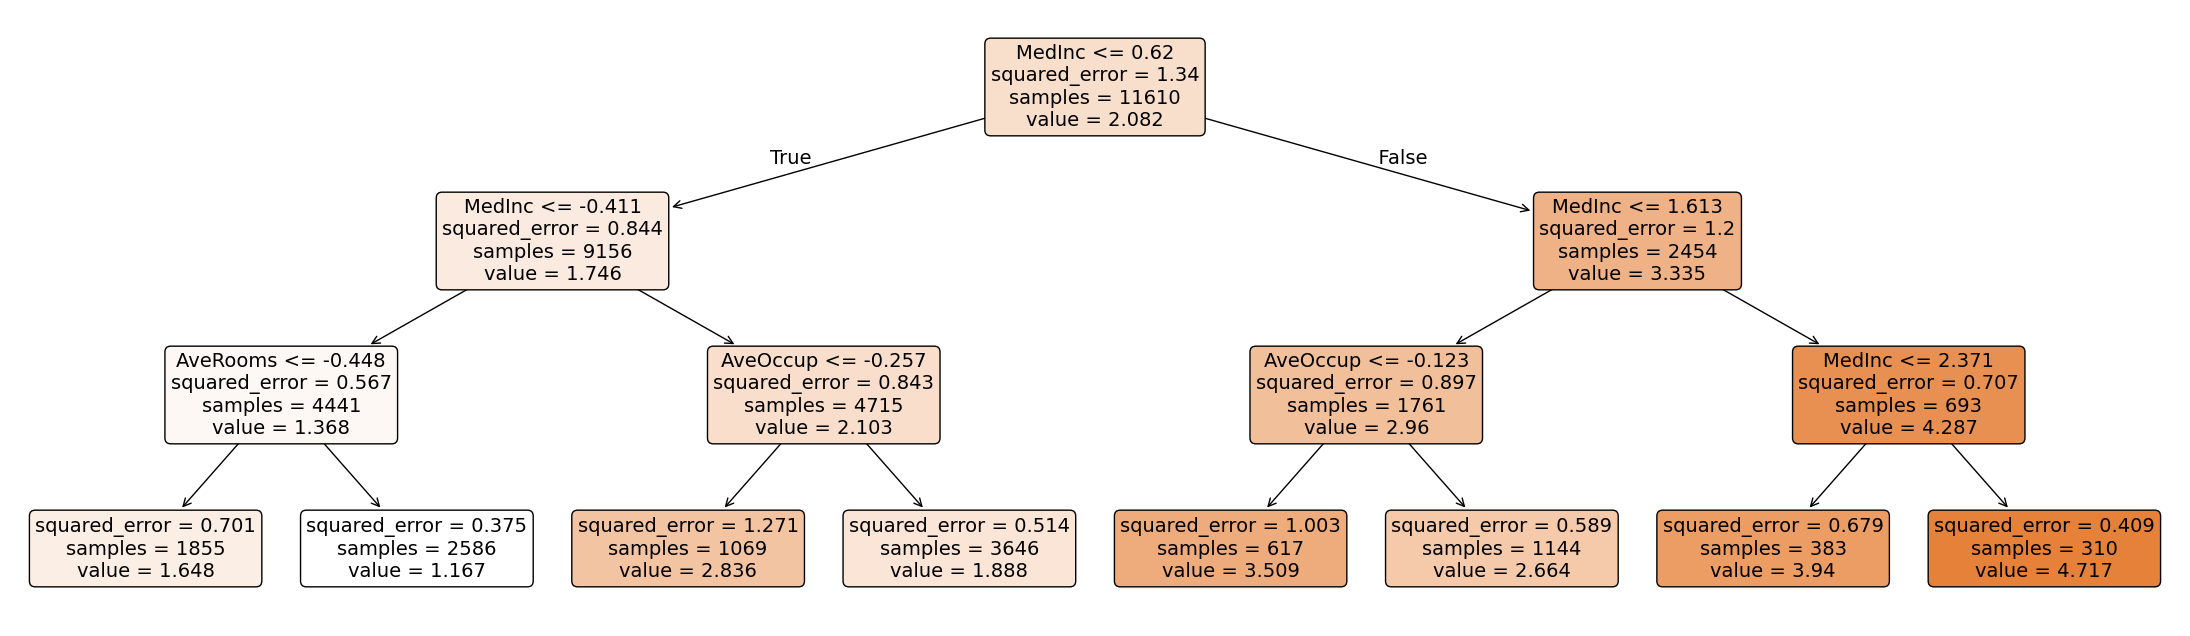

In [27]:
plt.figure(figsize=(28,8), facecolor='white')

# create the tree plot

a=tree.plot_tree(dt_reg_pipeline[-1],
                #  use the feature names stored,
                feature_names=features.columns,
                rounded=True,
                filled=True,
                fontsize=14
                )

In [28]:
# 2. As a text based diagram
# export the decision rules
tree_rules=export_text(dt_reg_pipeline[-1])

print(tree_rules)


|--- feature_0 <= 0.62
|   |--- feature_0 <= -0.41
|   |   |--- feature_2 <= -0.45
|   |   |   |--- value: [1.65]
|   |   |--- feature_2 >  -0.45
|   |   |   |--- value: [1.17]
|   |--- feature_0 >  -0.41
|   |   |--- feature_5 <= -0.26
|   |   |   |--- value: [2.84]
|   |   |--- feature_5 >  -0.26
|   |   |   |--- value: [1.89]
|--- feature_0 >  0.62
|   |--- feature_0 <= 1.61
|   |   |--- feature_5 <= -0.12
|   |   |   |--- value: [3.51]
|   |   |--- feature_5 >  -0.12
|   |   |   |--- value: [2.66]
|   |--- feature_0 >  1.61
|   |   |--- feature_0 <= 2.37
|   |   |   |--- value: [3.94]
|   |   |--- feature_0 >  2.37
|   |   |   |--- value: [4.72]



In [29]:
# using the tree for prediction
test_labels_pred=dt_reg_pipeline.predict(test_features)


In [30]:
# Evaluating the tree

mae=mean_absolute_error(test_labels,test_labels_pred)
mse=mean_squared_error(test_labels,test_labels_pred)
r2=r2_score(test_labels,test_labels_pred)

print(" The model performance for testing set")
print(f" Mean Absolute Error: {mae}")
print(f" Mean Squared Error: {mse}")
print(f" R-squared: {r2}")

 The model performance for testing set
 Mean Absolute Error: 0.6005762942842664
 Mean Squared Error: 0.6417557936098145
 R-squared: 0.5150037690483743


In [31]:
# let us now try to improve the performance of the model by tuning the hyperparameters
param_grid={
  'dt_reg__max_depth':range(1,20),
  'dt_reg__min_samples_split':range(2,8)
}

dt_grid_search=GridSearchCV(dt_reg_pipeline,
                            param_grid=param_grid,
                            n_jobs=2,
                            cv=cv,
                            scoring='neg_mean_absolute_error',
                            return_train_score=True
                            )
dt_grid_search.fit(com_train_features,com_train_labels)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'dt_reg__max_depth': range(1, 20), 'dt_reg__min_samples_split': range(2, 8)}"
,scoring,'neg_mean_absolute_error'
,n_jobs,2
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [32]:
mean_train_error=-1*dt_grid_search.cv_results_['mean_train_score'][dt_grid_search.best_index_]
mean_test_error=-1*dt_grid_search.cv_results_['mean_test_score'][dt_grid_search.best_index_]
print(f"Best Hyperparameters: {dt_grid_search.best_params_}")
print(f"Mean Train Error: {mean_train_error}")
print(f"Mean Test Error: {mean_test_error}")  
std_train_error=-1*dt_grid_search.cv_results_['std_train_score'][dt_grid_search.best_index_]
std_test_error=-1*dt_grid_search.cv_results_['std_test_score'][dt_grid_search.best_index_]
print(f"Std Train Error: {std_train_error}")  
print(f"Std Test Error: {std_test_error}")
  

Best Hyperparameters: {'dt_reg__max_depth': 11, 'dt_reg__min_samples_split': 7}
Mean Train Error: 0.2813005804313282
Mean Test Error: 0.4295233029030097
Std Train Error: -0.007029248234836672
Std Test Error: -0.011378669299188692


In [36]:
print("Best Hyperparameters:", dt_grid_search.best_params_)
print("Mean Cross Validated score of the best estimator is : ",-1*dt_grid_search.best_score_)

Best Hyperparameters: {'dt_reg__max_depth': 11, 'dt_reg__min_samples_split': 7}
Mean Cross Validated score of the best estimator is :  0.4295233029030097


In [39]:
# let's retrain the model with the best hyperparameters and evaluate on the test set
dt_reg_pipeline.set_params(
  dt_reg__max_depth=11,
  dt_reg__min_samples_split=5,

).fit(com_train_features,com_train_labels)

,steps,"[('feature_scaling', ...), ('dt_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'squared_error'
,splitter,'best'
,max_depth,11
,min_samples_split,5


In [40]:
test_labels_pred=dt_reg_pipeline.predict(test_features)
mae=mean_absolute_error(test_labels,test_labels_pred)
mse=mean_squared_error(test_labels,test_labels_pred)
r2=r2_score(test_labels,test_labels_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")



Mean Absolute Error: 0.4248952183820017
Mean Squared Error: 0.4154957726373763
R-squared Score: 0.6859960039130073
